In [1]:
import numpy as np
import pandas as pd
import xarray as xr
from pathlib import Path
import plotly.express as px
import geopandas as gpd

In [2]:
data_path = Path("data/gmb_data")
datafile_path = data_path / "ts_monthly_const_area_lstm.csv"
df = pd.read_csv(datafile_path)
df.head()

,Unnamed: 0,1979-01,1979-02,1979-03,1979-04,1979-05,1979-06,1979-07,1979-08,1979-09,...,2022-03,2022-04,2022-05,2022-06,2022-07,2022-08,2022-09,2022-10,2022-11,2022-12
0,RGI60-02.00001,0.2872,1.1940,0.2923,0.2739,-0.2123,-0.6590,-1.4372,-1.4510,-0.9186,...,0.6305,0.6026,0.0298,-0.7529,-1.7404,-1.7858,-1.0455,-0.0051,0.6792,0.9514
1,RGI60-02.00002,0.2917,1.2207,0.2978,0.3481,-0.1443,-0.8161,-1.5589,-1.6001,-0.9996,...,0.7489,0.6550,-0.1853,-0.8741,-1.7743,-1.9227,-1.0947,-0.0429,0.6970,0.9516
2,RGI60-02.00003,0.2433,0.9439,0.1916,0.2506,-0.0884,-0.6414,-1.4383,-1.3902,-0.8557,...,0.5063,0.4662,0.0437,-0.6042,-1.6652,-1.7486,-0.9713,0.0033,0.5604,0.7560
3,RGI60-02.00004,0.4080,1.7072,0.2560,0.4754,-0.2685,-1.0280,-1.8634,-1.7821,-1.1334,...,1.0493,0.8676,-0.3168,-1.0331,-1.9681,-2.1468,-1.2470,0.0829,0.9756,1.2738
4,RGI60-02.00005,0.2850,1.1930,0.2869,0.3642,-0.0660,-0.7449,-1.5138,-1.5708,-0.9762,...,0.7425,0.6494,-0.1488,-0.8260,-1.7082,-1.9007,-1.0753,-0.0283,0.6819,0.9301


<Axes: >

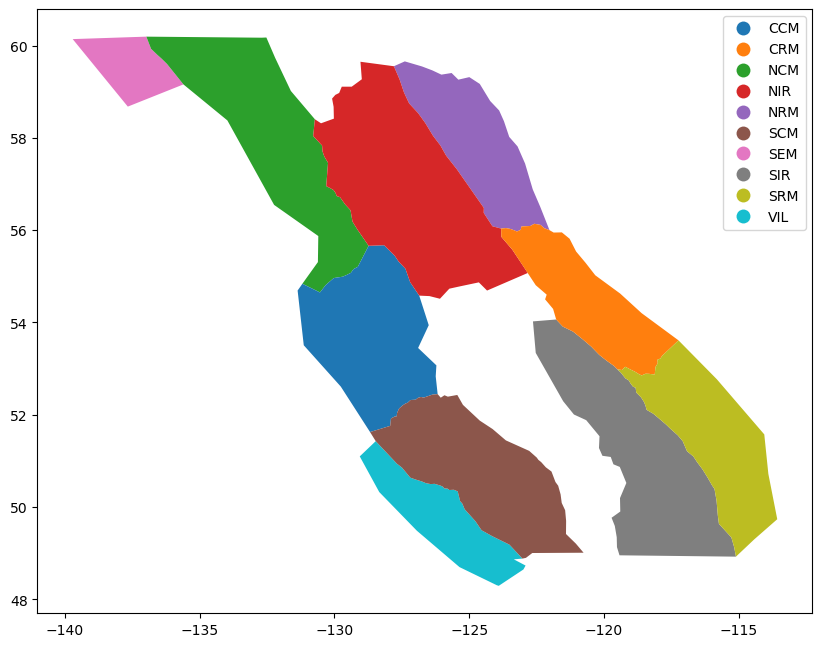

In [22]:
boundary_file = data_path / "bca_glacier_regions.shp"
bc_regions = gpd.read_file(boundary_file)
bc_regions = bc_regions.set_crs(epsg=3005, allow_override=True)  # only if you have high confidence
bc_regions = bc_regions.to_crs(epsg=4326)
indices = np.arange(len(bc_regions))
bc_regions['id'] = indices
bc_regions['name'] = [
    'VIL',
    'SIR',
    'NRM',
    'SEM',
    'NCM',
    'CCM',
    'SCM',
    'NIR',
    'CRM',
    'SRM',
]
# plot with region index, with a tenth color for the unlabeled regions
bc_regions.plot(figsize=(10, 10), column='name', legend=True)

In [4]:
rgi_01 = data_path / "01_rgi60_Alaska.shp"
rgi_02 = data_path / "02_rgi60_WesternCanadaUS.shp"
rgi_01_gdf = gpd.read_file(rgi_01)
rgi_02_gdf = gpd.read_file(rgi_02)
rgi_01_gdf.head()
rgi_02_gdf.head()

,RGIId,GLIMSId,BgnDate,EndDate,CenLon,CenLat,O1Region,O2Region,Area,Zmin,...,Aspect,Lmax,Status,Connect,Form,TermType,Surging,Linkages,Name,geometry
0,RGI60-02.00001,G238765E49002N,20049999,20069999,-121.235,49.0019,2,4,0.073,1938,...,345,304,0,0,0,0,0,9,None,"POLYGON ((-121.23718 49.0012, -121.23707 49.00..."
1,RGI60-02.00002,G238410E49162N,20049999,20069999,-121.590,49.1617,2,4,0.262,1726,...,6,817,0,0,0,0,0,9,None,"POLYGON ((-121.59118 49.15868, -121.59118 49.1..."
2,RGI60-02.00003,G238791E49163N,20049999,20069999,-121.209,49.1627,2,4,0.307,2002,...,100,478,0,0,0,0,0,9,None,"POLYGON ((-121.20751 49.16608, -121.20669 49.1..."
3,RGI60-02.00004,G238399E49166N,20049999,20069999,-121.601,49.1657,2,4,0.184,1563,...,15,376,0,0,0,0,0,9,None,"POLYGON ((-121.59654 49.16729, -121.597 49.166..."
4,RGI60-02.00005,G238389E49167N,20049999,20069999,-121.611,49.1666,2,4,0.274,1668,...,50,676,0,0,0,0,0,9,None,"POLYGON ((-121.608 49.16802, -121.60803 49.167..."


In [11]:
rgi_02_gdf.columns

Index(['RGIId', 'GLIMSId', 'BgnDate', 'EndDate', 'CenLon', 'CenLat',
       'O1Region', 'O2Region', 'Area', 'Zmin', 'Zmax', 'Zmed', 'Slope',
       'Aspect', 'Lmax', 'Status', 'Connect', 'Form', 'TermType', 'Surging',
       'Linkages', 'Name', 'geometry'],
      dtype='object')

In [5]:
not_in_rgi = []
for rgi_id in df['Unnamed: 0']:
    if rgi_id not in rgi_01_gdf.index and rgi_id not in rgi_02_gdf.index:
        not_in_rgi.append(rgi_id)

In [24]:
rgi_ids = df['Unnamed: 0']
rgi_lats, rgi_lons = [], []
rgi_areas = []
rgi_aspects = []
rgi_zmeds = []
rgi_slopes = []
for rgi_id in rgi_ids:
    if rgi_id in rgi_01_gdf['RGIId'].values:
        row = rgi_01_gdf[rgi_01_gdf['RGIId'] == rgi_id]
    else:
        row = rgi_02_gdf[rgi_02_gdf['RGIId'] == rgi_id]
    rgi_lats.append(row["CenLat"].values[0])
    rgi_lons.append(row["CenLon"].values[0])
    rgi_areas.append(row["Area"].values[0])
    rgi_aspects.append(row["Aspect"].values[0])
    rgi_zmeds.append(row["Zmed"].values[0])
    rgi_slopes.append(row["Slope"].values[0])

# every column after "Unnamed: 0" is a time step
time_cols = df.columns[1:]
# Convert time columns to datetime objects
time_index = pd.to_datetime(time_cols, format='%Y-%m')

# create an xarray
xr_data = xr.DataArray(
    data=df[time_cols].values,
    dims=["glacier_id", "time"],
    coords={"glacier_id": rgi_ids, "time": time_index}
)
xr_data = xr_data.assign_coords(Lat=("glacier_id", rgi_lats))
xr_data = xr_data.assign_coords(Lon=("glacier_id", rgi_lons))
xr_data = xr_data.assign_coords(Area=("glacier_id", rgi_areas))
xr_data = xr_data.assign_coords(Aspect=("glacier_id", rgi_aspects))
xr_data = xr_data.assign_coords(Zmed=("glacier_id", rgi_zmeds))
xr_data = xr_data.assign_coords(Slope=("glacier_id", rgi_slopes))
xr_data.name = "GMB"
xr_ds = xr_data.to_dataset()

In [25]:
xr_ds.head()

<xarray.Dataset> Size: 480B
Dimensions:     (glacier_id: 5, time: 5)
Coordinates:
  * glacier_id  (glacier_id) object 40B 'RGI60-02.00001' ... 'RGI60-02.00005'
  * time        (time) datetime64[ns] 40B 1979-01-01 1979-02-01 ... 1979-05-01
    Lat         (glacier_id) float64 40B 49.0 49.16 49.16 49.17 49.17
    Lon         (glacier_id) float64 40B -121.2 -121.6 -121.2 -121.6 -121.6
    Area        (glacier_id) float64 40B 0.073 0.262 0.307 0.184 0.274
    Aspect      (glacier_id) int32 20B 345 6 100 15 50
    Zmed        (glacier_id) int32 20B 2039 1962 2127 1669 1937
    Slope       (glacier_id) float64 40B 29.0 29.6 31.0 25.3 28.5
Data variables:
    GMB         (glacier_id, time) float64 200B 0.2872 1.194 ... 0.3642 -0.066

In [26]:
# find glaciers which have any NaN values
nan_glaciers = xr_ds['GMB'].isnull().any(dim='time')

print("Glaciers with NaN values in GMB data:")
for glacier_id in xr_ds['glacier_id'].values:
    if nan_glaciers.sel(glacier_id=glacier_id).values:
        nan_count = xr_ds['GMB'].sel(glacier_id=glacier_id).isnull().sum().values
        print(f"Glacier ID: {glacier_id} has {nan_count} NaN values.")

# remove glaciers with NaN values
xr_ds_clean = xr_ds.sel(glacier_id=~nan_glaciers)



Glaciers with NaN values in GMB data:
Glacier ID: RGI60-01.01125 has 528 NaN values.
Glacier ID: RGI60-01.20630 has 528 NaN values.
Glacier ID: RGI60-01.26654 has 528 NaN values.
Glacier ID: RGI60-01.26655 has 528 NaN values.


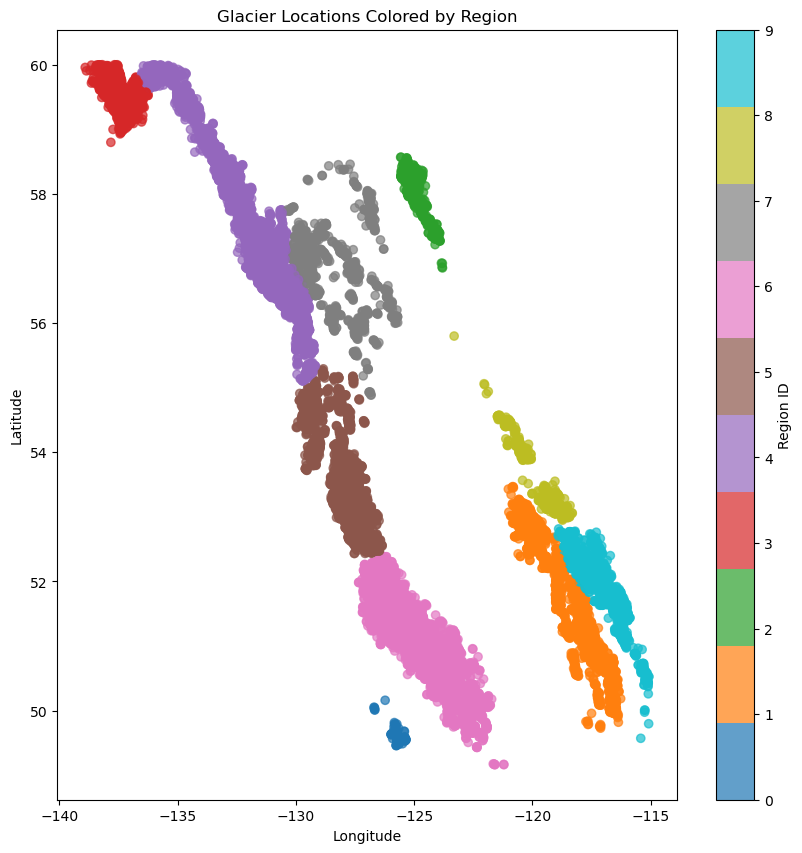

In [27]:
# add region name and id based on glacier lat/lon
def assign_region(row, regions_gdf):
    point = gpd.points_from_xy([row['Lon']], [row['Lat']])
    point_gdf = gpd.GeoDataFrame(geometry=point, crs=regions_gdf.crs)
    joined = gpd.sjoin(point_gdf, regions_gdf, how='left', predicate='within')
    if not joined.empty and 'name' in joined.columns:
        return joined.iloc[0]['name'], joined.iloc[0]['id']
    else:
        return 'Unlabeled', -1
    
region_names = []
region_ids = []
for glacier_id in xr_ds_clean['glacier_id'].values:
    row = {
        'Lon': xr_ds_clean['Lon'].sel(glacier_id=glacier_id).values,
        'Lat': xr_ds_clean['Lat'].sel(glacier_id=glacier_id).values
    }
    name, id_ = assign_region(row, bc_regions)
    region_names.append(name)
    region_ids.append(id_)

xr_ds_clean = xr_ds_clean.assign_coords(Region_Name=("glacier_id", region_names))
xr_ds_clean = xr_ds_clean.assign_coords(Region_ID=("glacier_id", region_ids))

# plot glaciers colored by region
from matplotlib import pyplot as plt
plt.figure(figsize=(10, 10))
plt.scatter(xr_ds_clean['Lon'], xr_ds_clean['Lat'], c=xr_ds_clean['Region_ID'], cmap='tab10', alpha=0.7)
plt.colorbar(label='Region ID')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Glacier Locations Colored by Region')
plt.show()

In [28]:
xr_ds_clean.head()

<xarray.Dataset> Size: 1kB
Dimensions:      (glacier_id: 5, time: 5)
Coordinates:
  * glacier_id   (glacier_id) object 40B 'RGI60-02.00001' ... 'RGI60-02.00005'
  * time         (time) datetime64[ns] 40B 1979-01-01 1979-02-01 ... 1979-05-01
    Lat          (glacier_id) float64 40B 49.0 49.16 49.16 49.17 49.17
    Lon          (glacier_id) float64 40B -121.2 -121.6 -121.2 -121.6 -121.6
    Area         (glacier_id) float64 40B 0.073 0.262 0.307 0.184 0.274
    Aspect       (glacier_id) int32 20B 345 6 100 15 50
    Zmed         (glacier_id) int32 20B 2039 1962 2127 1669 1937
    Slope        (glacier_id) float64 40B 29.0 29.6 31.0 25.3 28.5
    Region_Name  (glacier_id) <U32 640B 'nan' 'SCM' 'SCM' 'SCM' 'SCM'
    Region_ID    (glacier_id) float64 40B nan 6.0 6.0 6.0 6.0
Data variables:
    GMB          (glacier_id, time) float64 200B 0.2872 1.194 ... 0.3642 -0.066

In [30]:
outfile = data_path / ".." / "GMB_monthly_meta.nc"
xr_ds_clean.to_netcdf(outfile, format="NETCDF4")

In [ ]:
outfile

In [29]:
nan_glaciers = xr_ds_clean['GMB'].isnull().any(dim='time')

print("Glaciers with NaN values in GMB data:")
for glacier_id in xr_ds_clean['glacier_id'].values:
    if nan_glaciers.sel(glacier_id=glacier_id).values:
        nan_count = xr_ds_clean['GMB'].sel(glacier_id=glacier_id).isnull().sum().values
        print(f"Glacier ID: {glacier_id} has {nan_count} NaN values.")

Glaciers with NaN values in GMB data:
